# Prediction of Academic Dropout and Academic Success: Comparative Analysis of Machine Learning Models

##### _Libraries_

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay
import seaborn as sns
import os

## Exploratory Data Analysis (EDA) & Preprocessing
##### **0. Importing the dataset**

In [2]:
data = pd.read_csv('data/raw/data.csv', sep=';')

data.columns = (
    data.columns
    .str.strip()        
    .str.replace('\t', '', regex=False)  
)

Numerical_data = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]
numeric_cols = [col for col in Numerical_data if col in data.columns]
print("Dataset Loaded Correctly. Shape:", data.shape)
print(f"A number of {len(numeric_cols)} real numeical columns have been detected.")

Dataset Loaded Correctly. Shape: (4424, 37)
A number of 18 real numeical columns have been detected.


In [3]:
print(numeric_cols)

['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


##### **1. Descriptive Statistics & Visaluzations**
First, let's analyze the general distribution of our target variable to see if the dataset is balanced, and visualize how some key categorical variables behave.

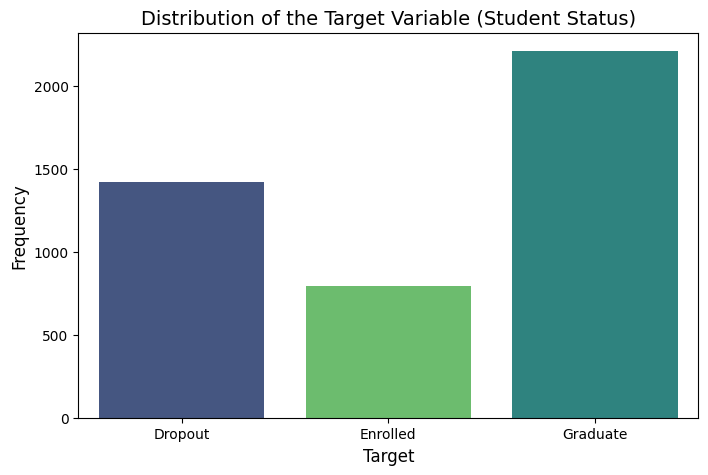

In [4]:
# Distribution of the Target Variable
plt.figure(figsize=(8, 5))
sns.countplot(
    data=data,
    x='Target',
    hue = 'Target',
    palette='viridis', 
    order=['Dropout', 'Enrolled', 'Graduate'],
    legend=False)

plt.title('Distribution of the Target Variable (Student Status)', fontsize=14)
plt.xlabel('Target', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

In [5]:
# Descriptive statistics for categorical variables
categorical_cols = [col for col in data.columns if col not in numeric_cols and col != 'Target']

print("Summary Statistics of Categorical Variables:")
display(data[categorical_cols].astype('object').describe())

Summary Statistics of Categorical Variables:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,International
count,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424
unique,6,18,8,17,2,17,21,29,34,32,46,2,2,2,2,2,2,2
top,1,1,1,9500,1,1,1,1,37,9,9,1,0,0,1,0,0,0
freq,3919,1708,3026,766,3941,3717,4314,1069,1209,1577,1010,2426,4373,3921,3896,2868,3325,4314


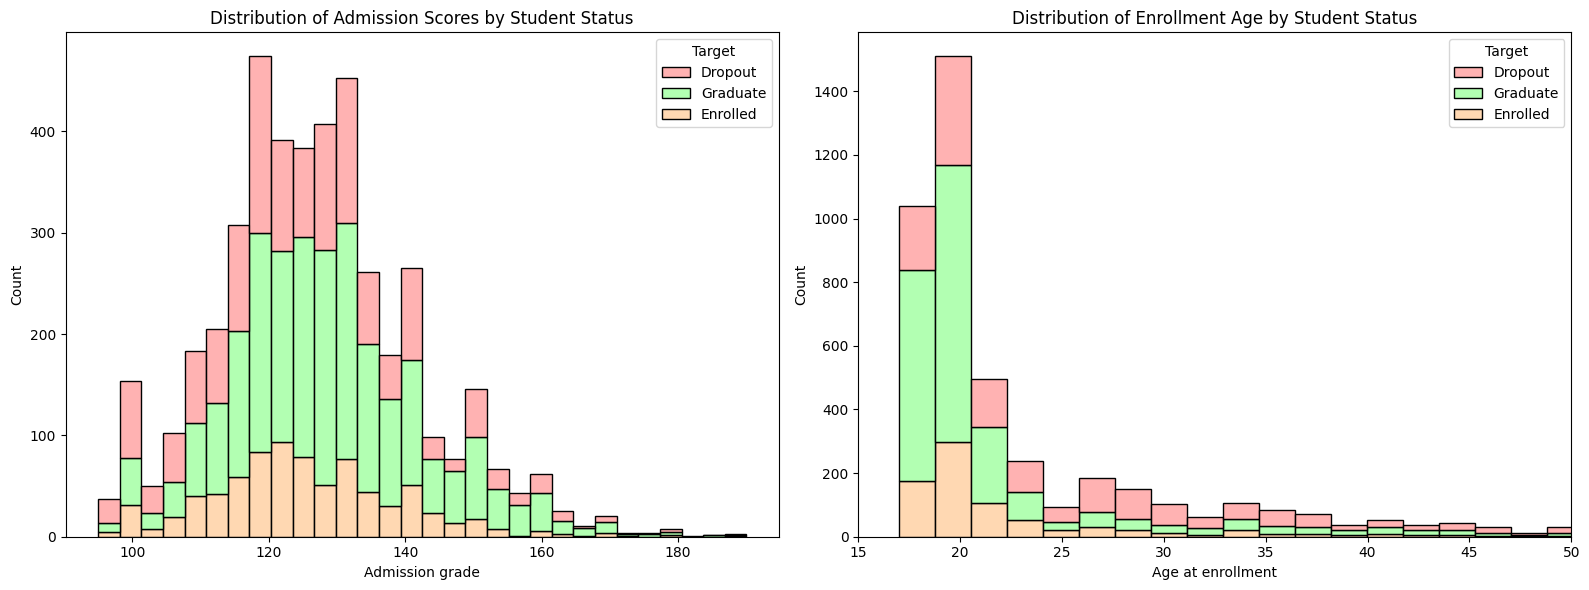

In [6]:
# Bivariate analysis: How do age and admission scores influence dropout rates?
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Admission Scores by Student's State
sns.histplot(data=data, 
             x='Admission grade',
             hue='Target',
             multiple="stack", 
             palette={'Dropout': '#ff9999', 'Enrolled': '#ffcc99', 'Graduate': '#99ff99'}, 
             ax=axes[0],
             bins=30)

axes[0].set_title('Distribution of Admission Scores by Student Status', fontsize=12)

# Enrollment Age by Student's State
sns.histplot(data=data, 
             x='Age at enrollment',
             hue='Target',
             multiple="stack", 
             palette={'Dropout': '#ff9999', 'Enrolled': '#ffcc99', 'Graduate': '#99ff99'}, 
             ax=axes[1],
             bins=30)
axes[1].set_title('Distribution of Enrollment Age by Student Status', fontsize=12)

axes[1].set_xlim(15, 50) # We've narrowed down the age range for better visibility

plt.tight_layout()
plt.show()

##### Bivariate Analysis: Age and Admission Grade vs Target

- **Admission Grade:**
Most students cluster in the 110-140 range. For scores under 120, the dropout rate (red) is noticeably higher than the graduation rate. Once grades pass the 130 mark, the trend reverses completely, with graduates (green) taking a clear lead. Basically, a better entrance score is a strong indicator that the student will stick with the program.

- **Age at Enrollment:**
The 18-20 age group makes up the vast majority of the dataset and shows the highest success rate. However, there's a sharp shift for older students: from age 25 onwards, dropouts heavily outnumber graduates. This makes sense, as older students usually have to balance their degree with jobs or family obligations, making them much more likely to abandon their studies.

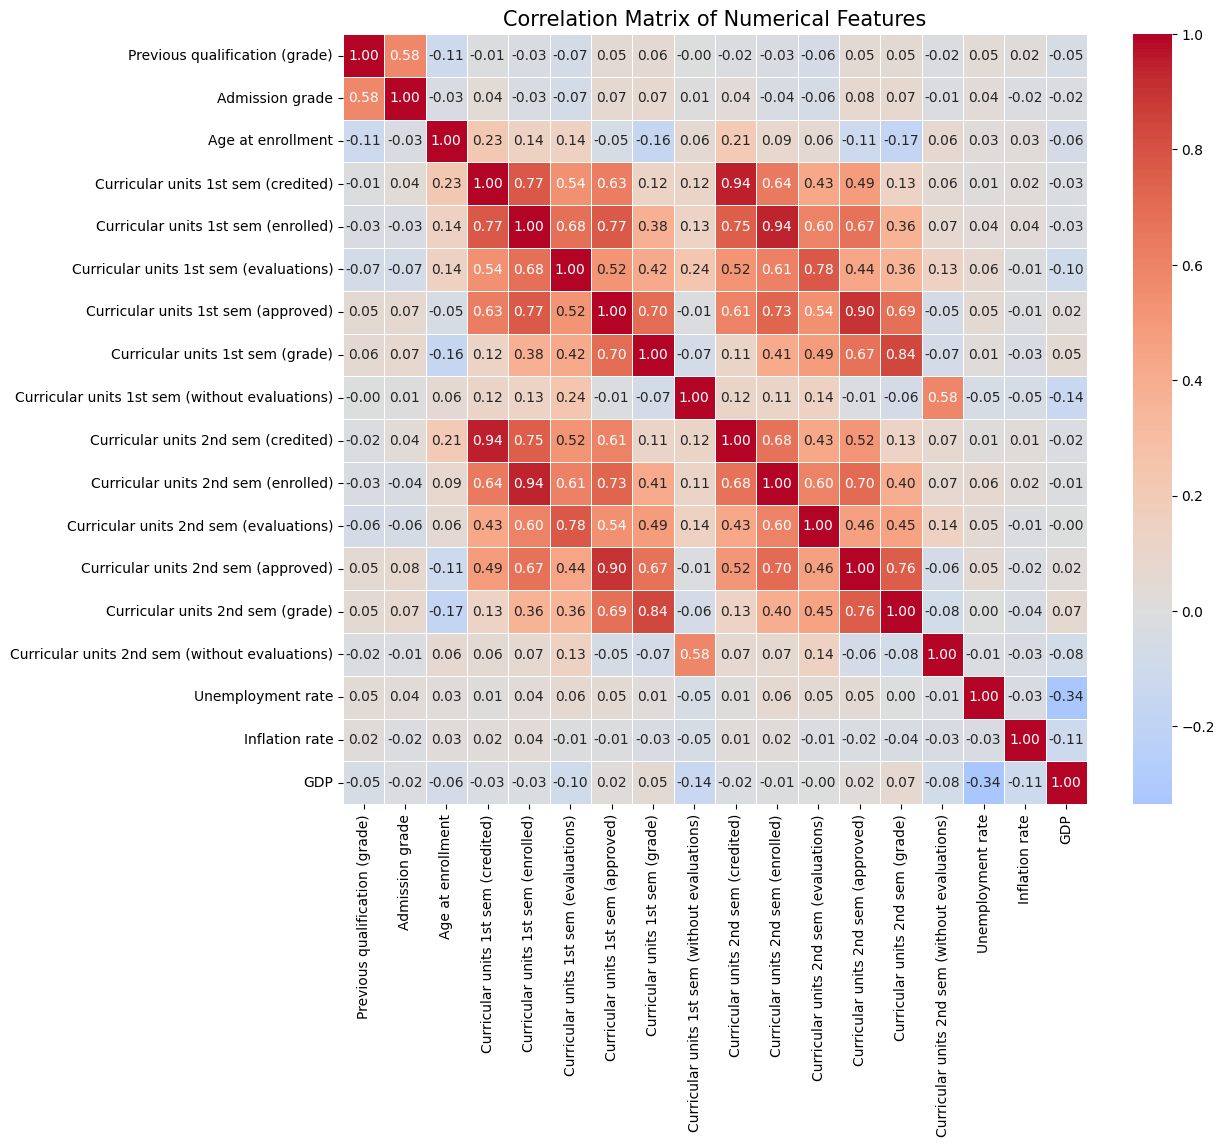

In [7]:
# Correlation Heatmap
plt.figure(figsize=(12,10))
correlation_matrix = data[numeric_cols].corr()

sns.heatmap(correlation_matrix,
            annot = True,
            cmap = 'coolwarm',
            fmt = '.2f',
            linewidths = 0.5,
            center = 0
           )
plt.title('Correlation Matrix of Numerical Features', fontsize = 15)
plt.show()

##### **2. Feature Selection**
To ensure model interpretability and avoid multicollinearity (which can confuse the model), we will use the previously obtained Pearson's correlation matrix for numerical variables, using the heatmap to identify and drop redundant variables (features that give the exact same information). Finally, we'll plot a bar chart to see which features provide the most information about our Target.

In [8]:
# Identify and remove highly correlated variables (Threshold > 0.85)

# If two variables have > 0.85 correlation, they are redundant. We keep one and drop the other.
threshold = 0.85

upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column].abs() > threshold)]

print(f"Highly correlated variables to be dropped (threshold > {threshold}): \n{to_drop}\n")

# Dropping the redundant variables from the dataset
data = data.drop(columns=to_drop, errors='ignore')

# Updating the Numerical_data list
n_before = len(numeric_cols)
numeric_cols = [col for col in numeric_cols if col in data.columns]

print(f"We have eliminated {n_before - len(numeric_cols)} variables for high correlation.")
print(f"We now work with {len(numeric_cols)} numerical variables")

Highly correlated variables to be dropped (threshold > 0.85): 
['Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)']

We have eliminated 3 variables for high correlation.
We now work with 15 numerical variables


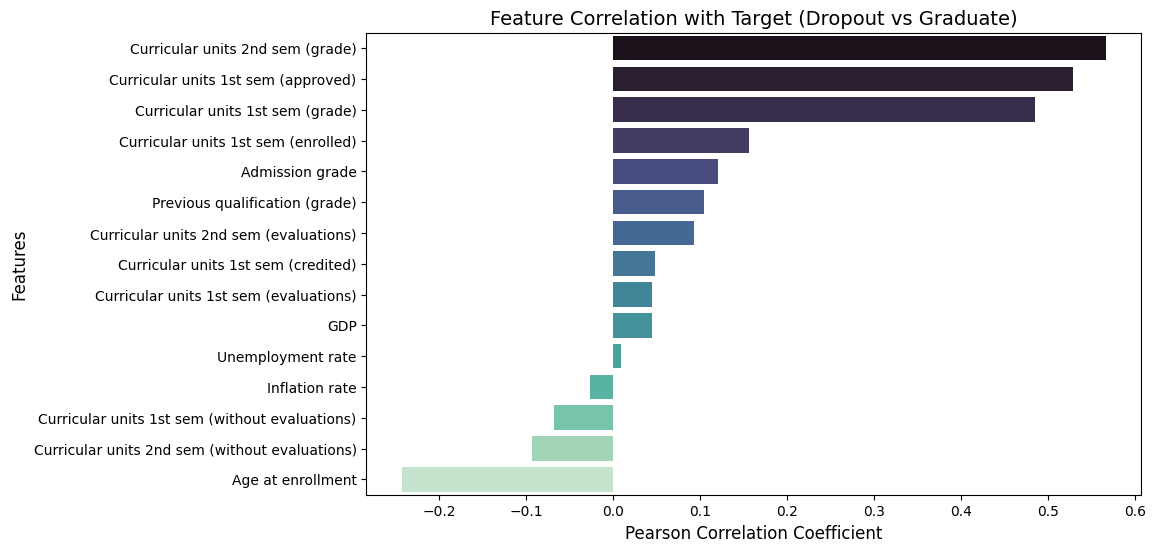

In [9]:
# Correlation with the Target
# Map Target to numerical values to calculate correlation (Dropout=0, Enrolled=1, Graduate=2)

data['Target_num'] = data['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})
target_corr = data[numeric_cols + ['Target_num']].corr()['Target_num'].drop('Target_num').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values,
            y=target_corr.index,
            hue=target_corr.index,
            palette='mako',
           legend=False)
plt.title('Feature Correlation with Target (Dropout vs Graduate)', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

# Remove the temporary numerical target column
data = data.drop(columns=['Target_num'])

##### **3. Novelty Factor: Macroeconomic Variables VS Dropout**
We visually investigate how external macroeconomic factors (Inflation, GDP, and Unemployment rate) behave against the student's status. This helps us understand if a bad economic context influences the abandonment of studies.

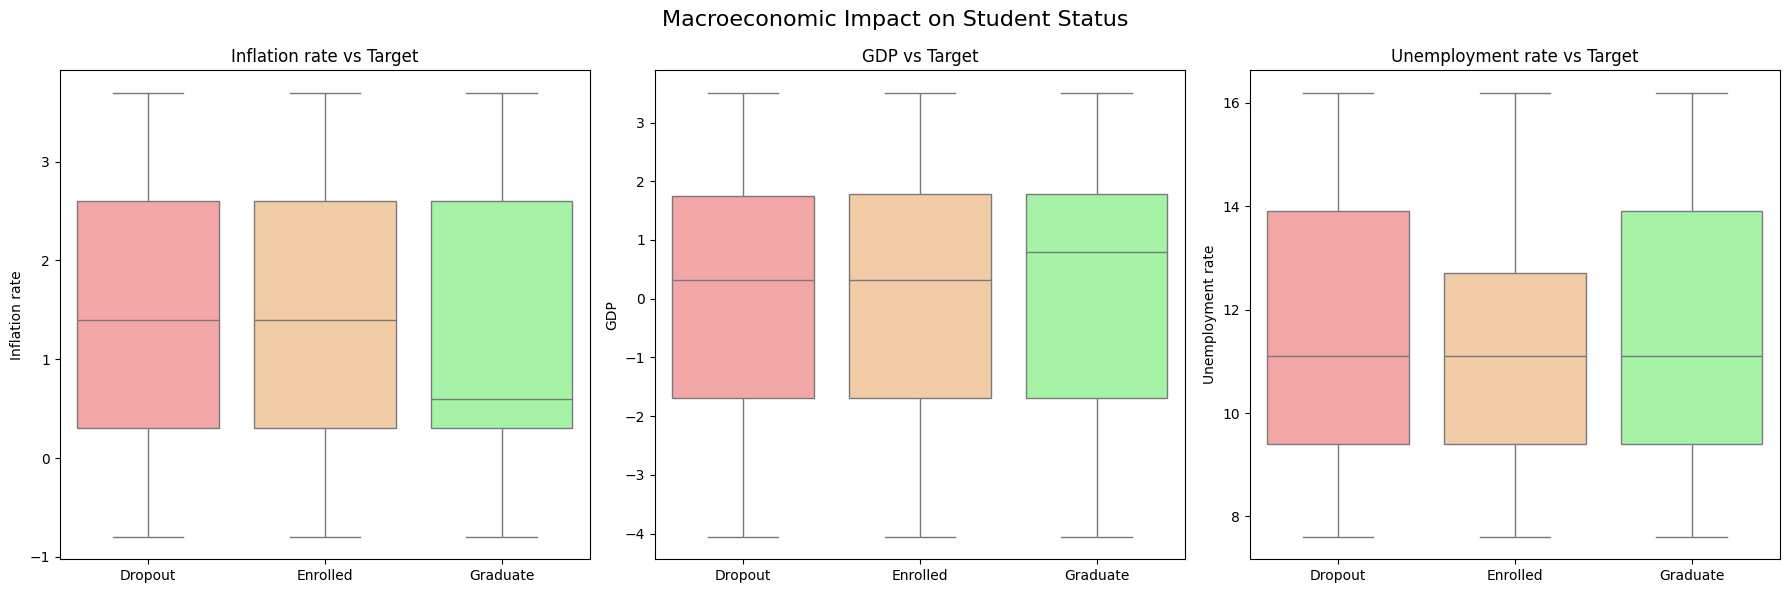

In [10]:
# Boxplots for Macroeconomic variables vs Target
macro_vars = ['Inflation rate', 'GDP', 'Unemployment rate']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Macroeconomic Impact on Student Status', fontsize=16)

palette_colors = {'Dropout': '#ff9999', 'Enrolled': '#ffcc99', 'Graduate': '#99ff99'}
target_order = ['Dropout', 'Enrolled', 'Graduate']

for i, col in enumerate(macro_vars):
    sns.boxplot(ax=axes[i], 
                data=data,
                x='Target',
                y=col,
                hue='Target',
                palette=palette_colors,
                order=target_order,
                legend=False
               )
    axes[i].set_title(f'{col} vs Target', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

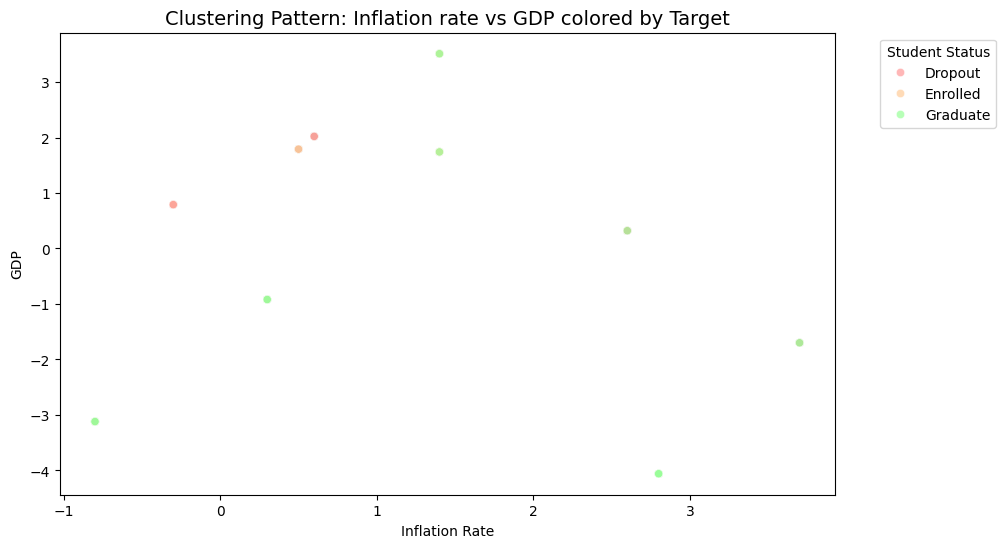

In [11]:
# Scatter plot to find clustering patterns between Inflation and GDP

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data,
                x='Inflation rate',
                y='GDP',
                hue='Target', 
                palette=palette_colors,
                alpha=0.7,
                hue_order=target_order)

plt.title('Clustering Pattern: Inflation rate vs GDP colored by Target', fontsize=14)
plt.xlabel('Inflation Rate')
plt.ylabel('GDP')
plt.legend(title='Student Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##### CONCLUSIONS REGARDING THE PATTERNS IDENTIFIED:
- **Curricular Redundancy:** There is a very high correlation between several 1st and 2nd-semester variables (like Curricular units enrolled vs evaluations). We can drop these overlapping features to make the model simpler to interpret without losing predictive power.

- **Academic Impact:** As expected, the number of approved curricular units and the grades obtained are the variables with the strongest positive correlation to student graduation. 
-  **Macroeconomic Influence (Novelty Factor):** Looking at the boxplots, dropouts tend to occur more frequently in periods with higher unemployment rates and lower GDP. This suggests that external economic conditions might play an important role in a student's decision to leave university.

##### **4. Data Preprocessing**

In [12]:
# Display the first few rows of the dataset
pd.set_option('display.max_columns', None) # To see all the columns
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,10,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [13]:
# Display summary statistics of the dataset
data.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,10.960895,11.032324,126.978119,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,23.265145,0.024864,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,8.063291,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,26.418253,25.263040,14.482001,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,7.587816,0.155729,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,3.947951,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,0.000000,0.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,4.000000,4.000000,117.900000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,6.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,5.000000,7.000000,126.100000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,8.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,9.000000,9.000000,134.800000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,10.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,194.000000,195.000000,190.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,1.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,33.000000,18.571429,12.000000,16.200000,3.700000,3.510000


Now, we differentiate between numerical & categorical data:

In [14]:
Numerical_data = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]
Categorical_data = [
    'Marital status',
    'Application mode',
    'Application order',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International'
]

##### **5. Inputation of Values**

In [15]:
# Search of Null values

null_counts = data.isnull().sum().sum()
print('Number of null values in the whole dataset:', null_counts)

Number of null values in the whole dataset: 0


To analyze the distribution of the data and choose the outliers that should be eliminated, we must use only numerical variables, because if we use categorical variables, we would probably eliminate data that are not atypical, since, for example, nationality is represented by an identification number that varies a lot.

Previous qualification (grade)
Admission grade
Age at enrollment: Since the vast majority of students are of similar ages, those who are older tend to be more responsible, usually have more obligations, and enroll in fewer subjects, etc. Therefore, outliers are eliminated as they are exceptional cases. 
Curricular units 1st sem (enrolled)
Curricular units 1st sem (approved)
Curricular units 1st sem (grade)
Curricular units 1st sem (without evaluations)
Curricular units 2nd sem (enrolled)
Curricular units 2nd sem (approved)
Curricular units 2nd sem (grade)
Curricular units 2nd sem (without evaluations)
Unemployment rate
Inflation rate
GDP

we don't need to remove or input because there are not null values

An amount of 15 numerical columns detected.


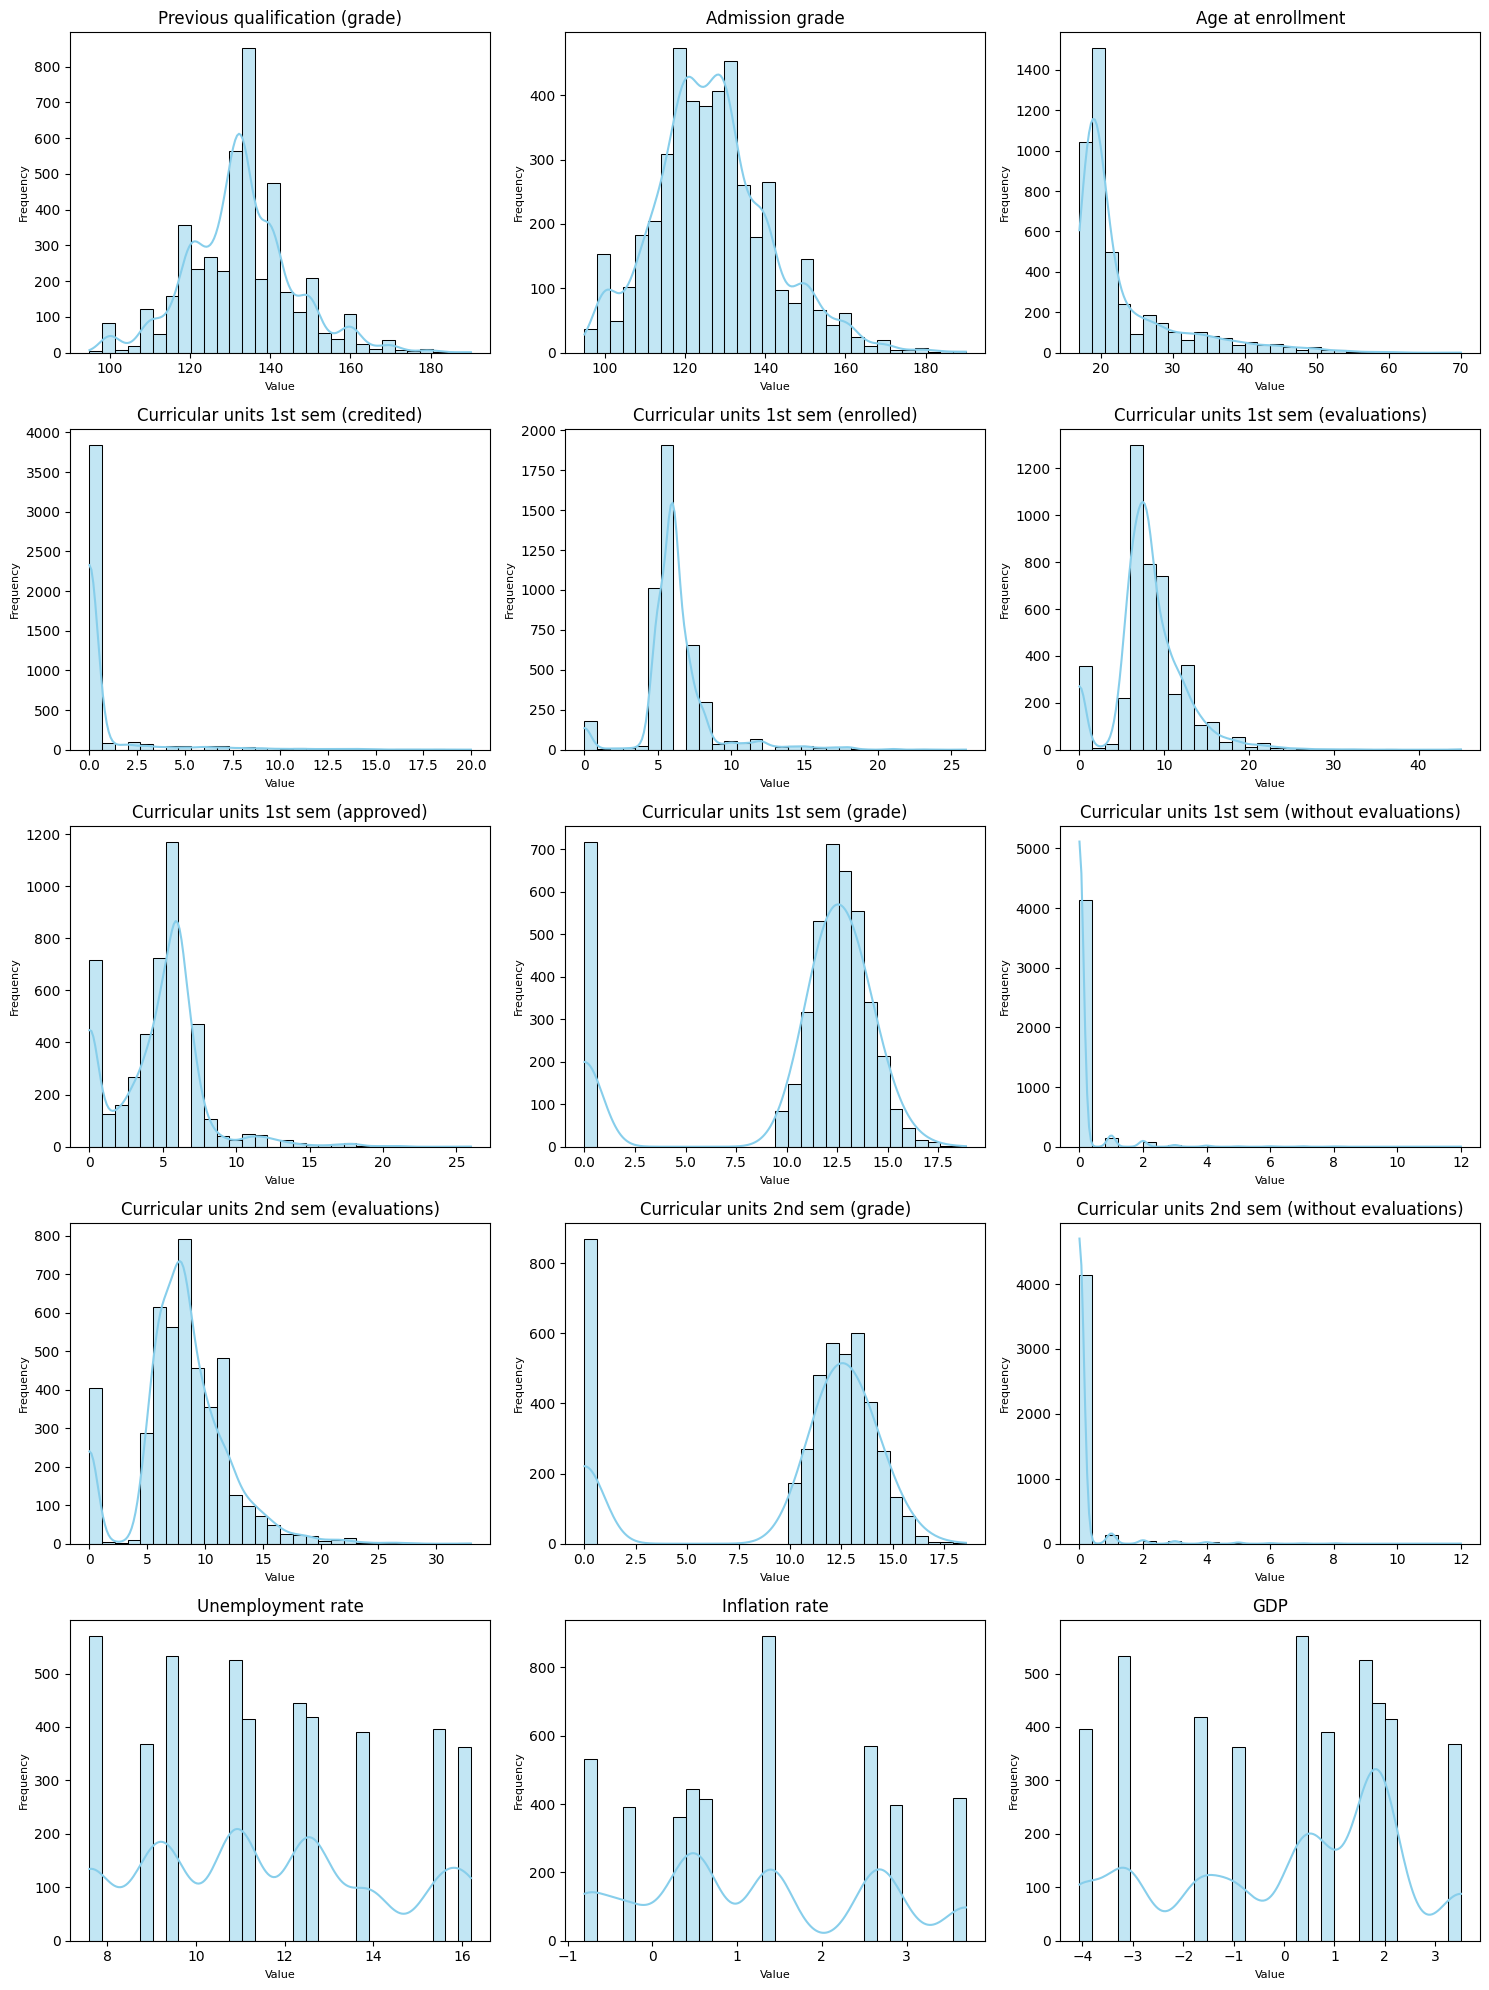

In [16]:
numeric_cols = [col for col in Numerical_data if col in data.columns]
print(f"An amount of {len(numeric_cols)} numerical columns detected.")

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data[col],
                 bins=30,
                 ax=axes[i],
                 kde=True,
                 color='skyblue'
                )
    axes[i].set_title(col, fontsize=12),
    axes[i].set_xlabel('Value', fontsize=8),
    axes[i].set_ylabel('Frequency', fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### **6. Outliers Management**

In [17]:
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    print(f"{col}: {outliers.shape[0]} outliers detectados")

Previous qualification (grade): 179 outliers detectados
Admission grade: 86 outliers detectados
Age at enrollment: 441 outliers detectados
Curricular units 1st sem (credited): 577 outliers detectados
Curricular units 1st sem (enrolled): 424 outliers detectados
Curricular units 1st sem (evaluations): 158 outliers detectados
Curricular units 1st sem (approved): 180 outliers detectados
Curricular units 1st sem (grade): 726 outliers detectados
Curricular units 1st sem (without evaluations): 294 outliers detectados
Curricular units 2nd sem (evaluations): 109 outliers detectados
Curricular units 2nd sem (grade): 877 outliers detectados
Curricular units 2nd sem (without evaluations): 282 outliers detectados
Unemployment rate: 0 outliers detectados
Inflation rate: 0 outliers detectados
GDP: 0 outliers detectados


Before removing rows with outliers, a box plot is drawn to visually analyze the behavior and how far away the outliers are located.

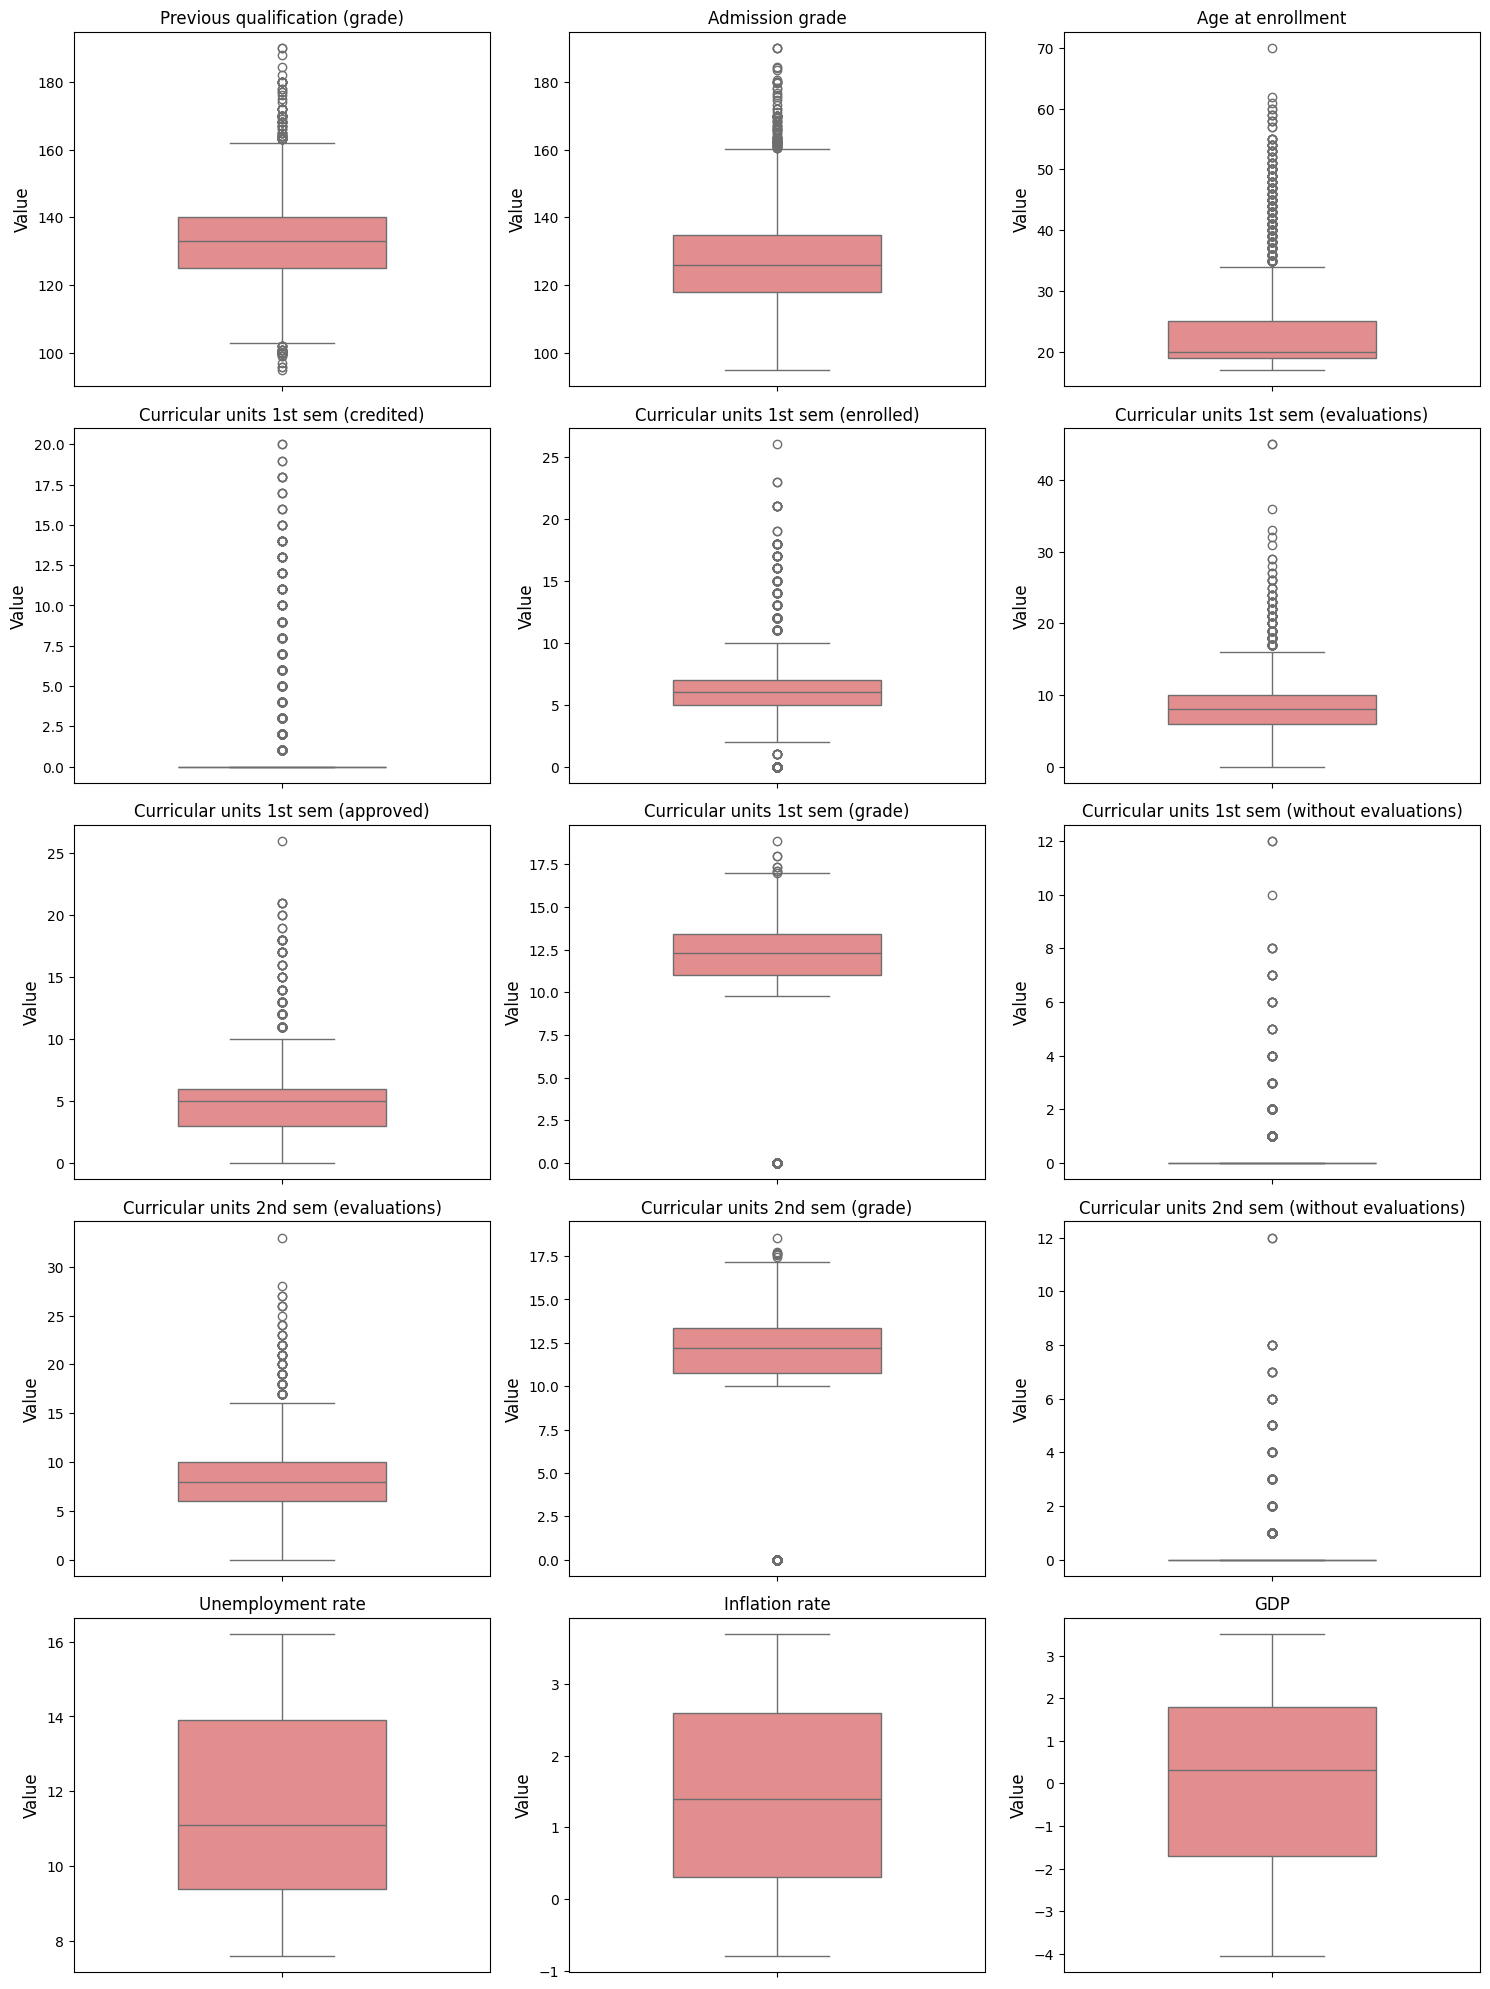

In [18]:
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

# Visualize
for i, col in enumerate(numeric_cols):
    sns.boxplot(data[col], 
                ax=axes[i],
                color='lightcoral',
               width=0.5)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Value', fontsize=12)

# Eliminate empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

After generating the initial box plots for the numerical features, a significant number of outliers were identified across several variables: **Age at enrollment**, **Curricular units (credited)** and **Academic grades**.

For academic performance, outliers at the lower bound (Grade = 0) represent thos students who failed or did not attend exams. Those are not real outliers but critical indicators of "Dropout" behavior.

The "Age at enrollment" variable shows a long tail of adult learners (30-50+ years old). These are essential for the model to understand the risk factors associated with those non-traditional' students. Therefore, we consider them important and don't delete them.

Variables like GPD and Inflation show specific economic cycles of the country, they don't appear to have outliers. 

We initially attempted to use a standard radical IQR filter (1.5 * IQR) which resulted in a drastic sample reduction (dropping from 4424 to approximately 2500 records). Such a loss of data, nearly 43% of the dataset, would have introduced a bias making the model only capable of predicting "average" students while ignoring the high-risk profiles.

Consequently, we decided to do a targeted cleaning approach, in which we filtered extreme values that likely represent data entry erros (like impossible amounts of evaluations or credits):

In [19]:
data_clean = data.copy()

data_clean = data_clean[data_clean['Curricular units 1st sem (evaluations)'] < 25]
data_clean = data_clean[data_clean['Curricular units 1st sem (credited)'] < 15]
data_clean = data_clean[data_clean['Curricular units 1st sem (without evaluations)'] < 5]

data = data_clean.copy()

print(f"Original lines: {data.shape[0]}")
print(f"Lines after cleaning extreme outliers: {data_clean.shape[0]}")


Original lines: 4369
Lines after cleaning extreme outliers: 4369


We have droped 55 lines (going from 4424 to 4369). With this approach, we are still keeping the integrity of the dataset while also removing extreme/irreal situations. Going from losing 43% of the dataset to only 1.2

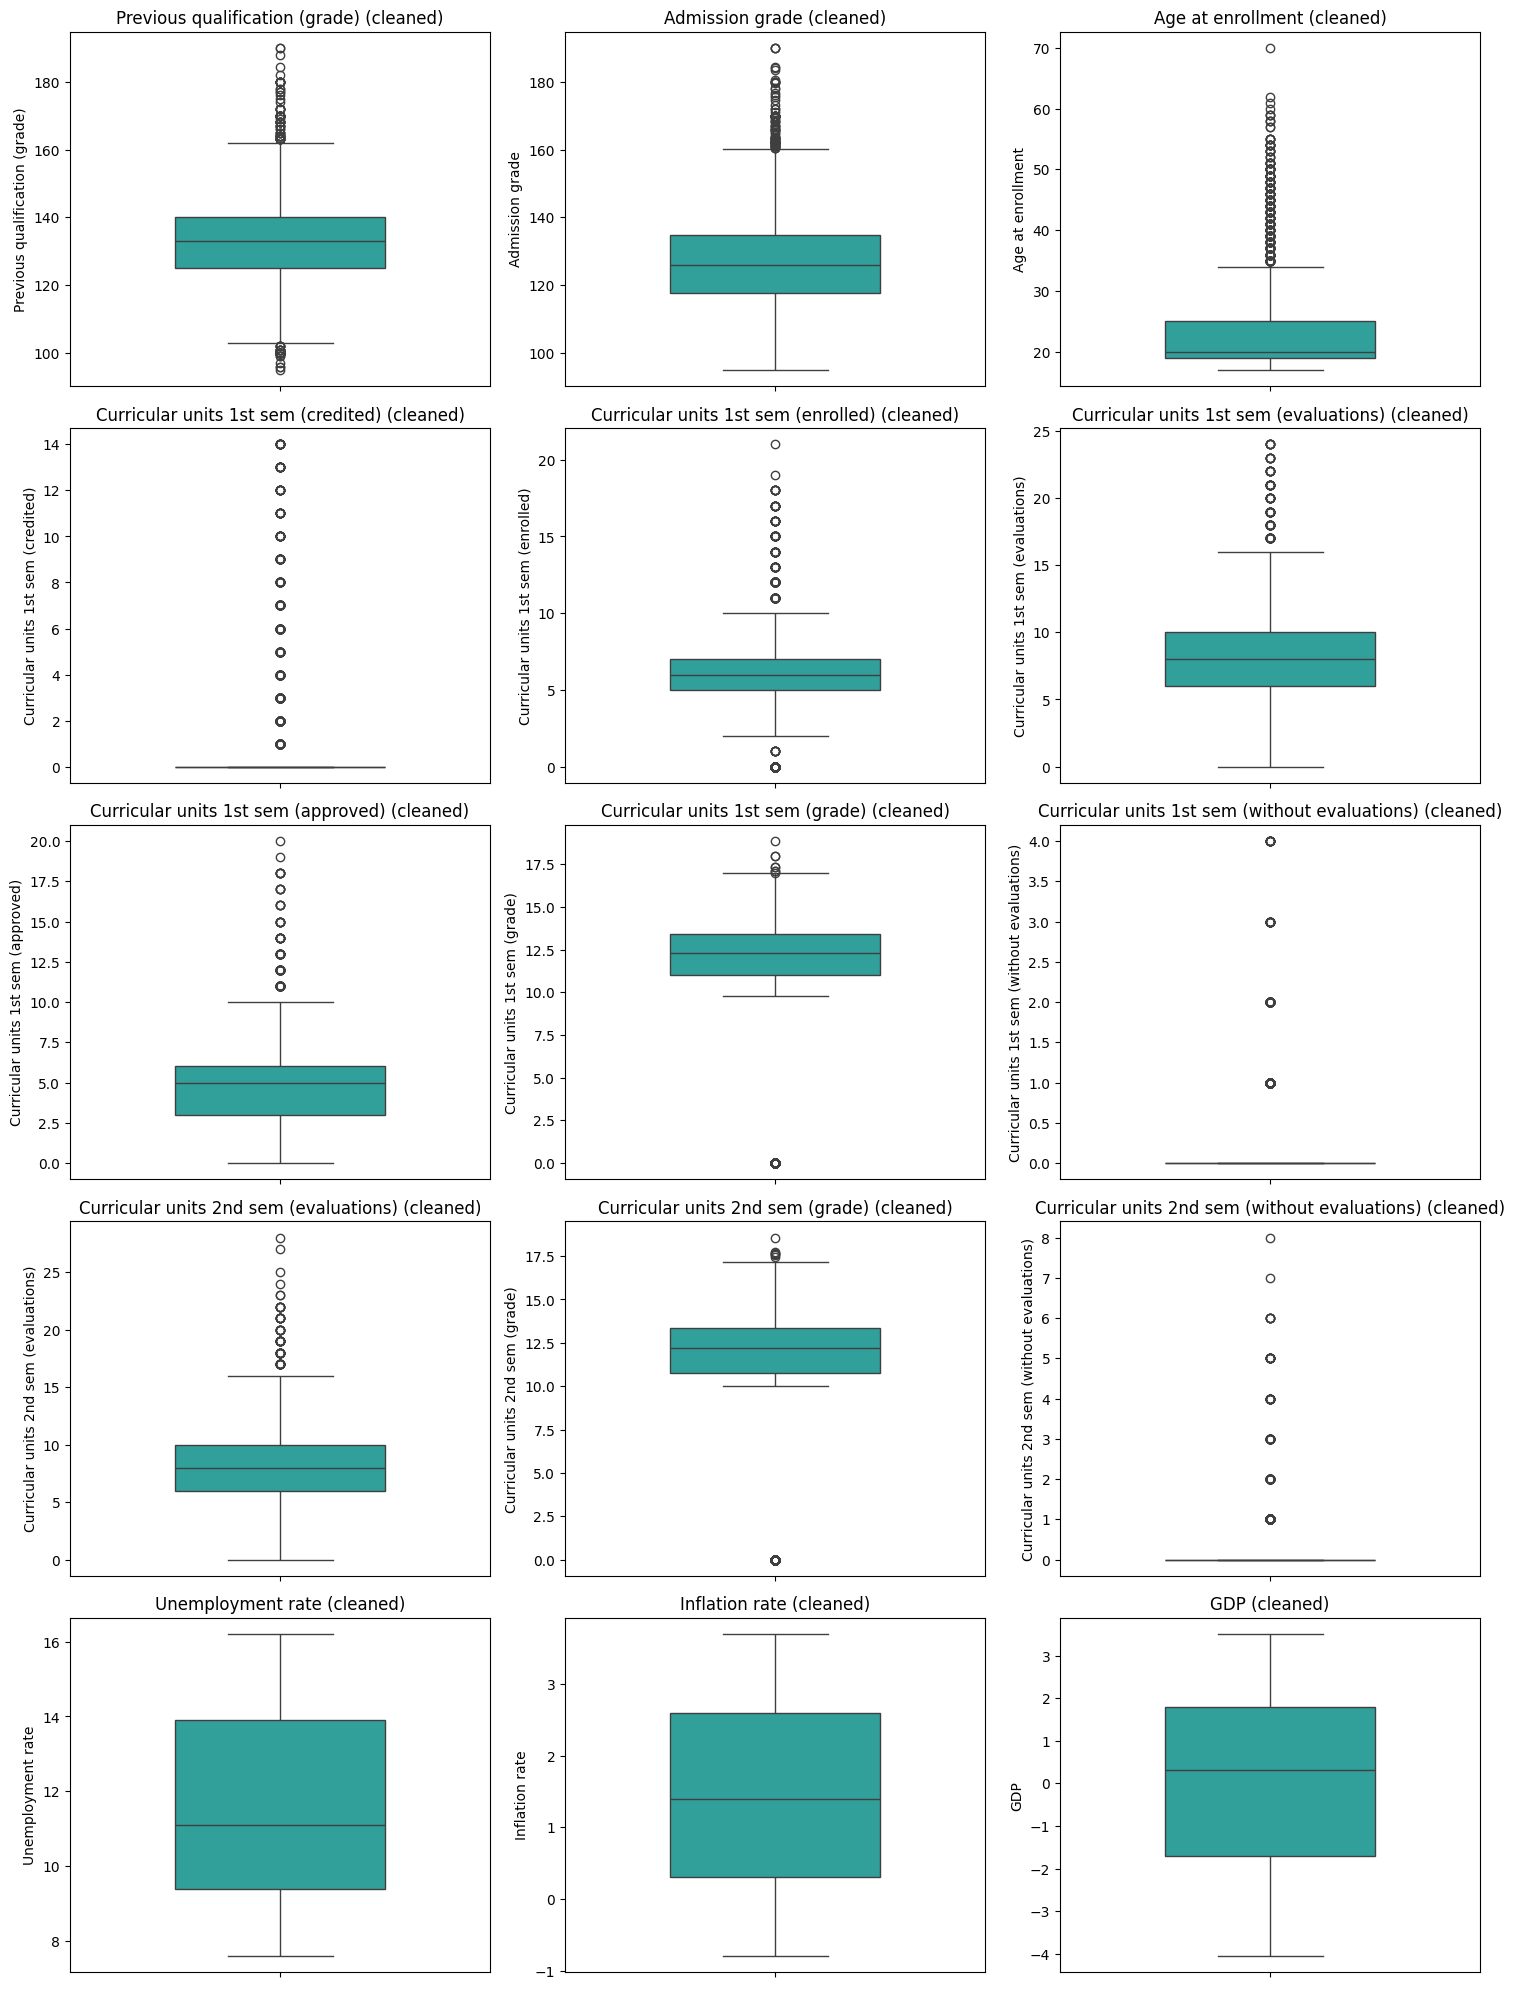

In [20]:
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

# Visualize
for i, col in enumerate(numeric_cols):
    sns.boxplot(data_clean[col], 
                ax=axes[i],
                color='lightseagreen',
                width=0.5)
    axes[i].set_title(f'{col} (cleaned)', fontsize = 12)

# Eliminate empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

By preserving 4369 rows, we ensure the model remains exposed to real-world diversity. To scale these rows to a comparable range, we will rely on **StandardScaler** used afterwards.

In [21]:
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,10,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,6,13.000000,0,13.9,-0.3,0.79,Graduate


##### **7. Data Splitting & Standarization**

Even though categorical features are already represented as numbers, they remain categorical, so we use one-hot-encoding to avoid artificial ordinal relationships between data whose numbers have no relation.

Before doing the data standarization, its needed to split the data to prevent data leakage. That way, we apply OneHotEncoding and StandardScaler to training and validaiton sets individually.

In [22]:
# Encoding of categorical features

X = data.drop(columns=['Target'])
y = data['Target']

# 80% Train 20% Test
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

categorical_features = [col for col in X.columns if col not in numeric_cols]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_train = encoder.fit_transform(X_train[categorical_features])
encoded_test = encoder.transform(X_test[categorical_features])

#Convert into DataFrame restoring the column names and original indexes
encoded_cols = encoder.get_feature_names_out(categorical_features)
encoded_train_df = pd.DataFrame(encoded_train, columns = encoded_cols, index = X_train.index)
encoded_test_df = pd.DataFrame(encoded_test, columns = encoded_cols, index = X_test.index)

#Replace the categorical columns (original ones) with the new ones (encoded)
X_train = pd.concat([X_train.drop(columns=categorical_features), encoded_train_df], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_features), encoded_test_df], axis=1)

print(f"Encoding complete. New shape of X_train:{X_train.shape}. New shape of x_test: {X_test.shape}")

Encoding complete. New shape of X_train:(3495, 243). New shape of x_test: (874, 243)


In [23]:
# Standarization of numerical features (StandardScaler)

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Standarization complete.")
print(f"X_train is now ready. Mean of numeric columns is now: {X_train[numeric_cols].mean()}")

Standarization complete.
X_train is now ready. Mean of numeric columns is now: Previous qualification (grade)                    9.860178e-16
Admission grade                                   4.879263e-16
Age at enrollment                                -9.860178e-17
Curricular units 1st sem (credited)               3.989814e-17
Curricular units 1st sem (enrolled)              -1.598467e-16
Curricular units 1st sem (evaluations)            4.574309e-17
Curricular units 1st sem (approved)               1.209651e-16
Curricular units 1st sem (grade)                  1.138495e-16
Curricular units 1st sem (without evaluations)    6.912290e-17
Curricular units 2nd sem (evaluations)            2.033026e-18
Curricular units 2nd sem (grade)                 -2.775081e-16
Curricular units 2nd sem (without evaluations)    3.659448e-17
Unemployment rate                                -2.317650e-16
Inflation rate                                    1.301137e-16
GDP                                    

To ensure a rigorous evaluation, we fitted the StandardScaler exclusively on the training data. We then applied the same transformation to the test set using .transform() instead of .fit_transform(). This prevents 'Data Leakage', ensuring that the model's performance metrics are calculated on truly unseen data distribution, mirroring a real-world deployment scenario.

## MODELING METHODOLOGY

##### **1. Logistic Regression**

Logistic Regression Accuracy: 0.7643020594965675
Classification Report:               precision    recall  f1-score   support

     Dropout       0.82      0.76      0.79       293
    Enrolled       0.52      0.32      0.39       154
    Graduate       0.78      0.93      0.85       427

    accuracy                           0.76       874
   macro avg       0.71      0.67      0.68       874
weighted avg       0.75      0.76      0.75       874



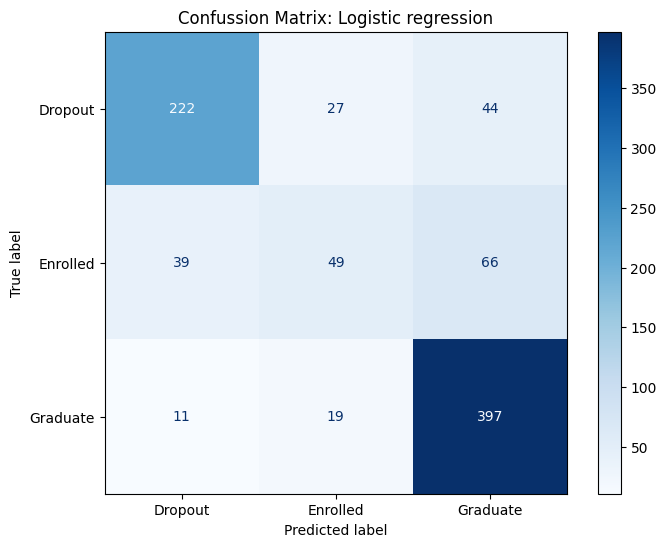

In [24]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy}")
print(f"Classification Report: {classification_report(y_test,y_pred)}")

fig, ax = plt.subplots(figsize=(8,6))
ConfusionMatrixDisplay.from_estimator(log_reg,
                                       X_test,
                                       y_test,
                                       display_labels=log_reg.classes_,
                                       cmap='Blues',
                                       ax=ax
                                      )
ax.set_title('Confussion Matrix: Logistic regression')
plt.show()

The model shows a strong performance in predicting polarized outcomes (Graduate and Dropout), achieving an overall accuracy of ~77%. The main bottleneck identified is the 'Enrolled' category, which the model frequently confuses with the other two classes. This is expected, as enrolled students represent a transitional state with overlapping feature distributions. For a baseline model, these results are highly satisfactory and provide a reliable foundation for further optimization.

In [25]:
os.makedirs("data/processed", exist_ok=True)
data.to_csv("data/processed/data_cleaned.csv", index=False)
